# 07 — Antes e depois das mudanças de regra

**Objetivo:** comparar os indicadores do MED entre os períodos definidos pelas
mudanças de regra da etapa 6 — e escrever com o mesmo cuidado o que essa
comparação **não** permite afirmar.

Faz parte da [etapa 9](../README.md#progresso) do projeto.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = "https://raw.githubusercontent.com/ivadivad/med-em-numeros/main/dados"
fraude = pd.read_csv(f"{RAW}/fraude.csv")
transacoes = pd.read_csv(f"{RAW}/transacoes.csv")

df = fraude.merge(transacoes, on="AnoMes", how="left", validate="one_to_one")
df["Data"] = pd.to_datetime(df["AnoMes"], format="%Y%m")
df = df.sort_values("Data").reset_index(drop=True)

df["Devolução (%)"] = df["PercentualdeDevolucao"]
df["Taxa de aceite (%)"] = df["Qtdecontestacoesaceitas"] / df["QtdePixcontestados"] * 100
df["Pedidos por milhão de transações"] = df["QtdePixcontestados"] / df["QUANTIDADE"] * 1e6
df["Aceitas por milhão de transações"] = df["Qtdecontestacoesaceitas"] / df["QUANTIDADE"] * 1e6
indicadores = ["Devolução (%)", "Taxa de aceite (%)", "Pedidos por milhão de transações", "Aceitas por milhão de transações"]
df.shape

(52, 32)

## Os períodos

Os cortes vêm das datas da etapa 6, **não escolhidos a olhando o gráfico**:

| Data | Mudança |
|---|---|
| 01/10/2025 | Botão de contestação 100% digital |
| 23/11/2025 | MED 2.0 (rastreio em outras contas), facultativo |
| 02/02/2026 | MED 2.0 obrigatório |

Os dados são mensais e as datas não caem no dia 1, então precisei de uma
regra: **cada mês vai pro regime que vigorou na maior parte dele.** Novembro
de 2025 teve 22 dias antes do MED 2.0 facultativo, então fica no período do
botão; fevereiro de 2026 teve 27 dias de MED 2.0 obrigatório.

Uma escolha que não vem das datas: **o tamanho do "antes".** O período anterior
ao botão tem 45 meses, e as etapas 5 e 7 mostraram que alguns indicadores
vinham numa tendência longa nesse intervalo. Por isso a tabela traz dois
"antes": o período inteiro e só os 12 meses anteriores.

In [2]:
periodos = [
    ("Antes do botão (jan/22–set/25)", 202201, 202509),
    ("12 meses antes (out/24–set/25)", 202410, 202509),
    ("Botão digital (out–nov/25)", 202510, 202511),
    ("MED 2.0 facultativo (dez/25–jan/26)", 202512, 202601),
    ("MED 2.0 obrigatório (fev–abr/26)", 202602, 202604),
]

def resumo(indicador):
    linhas = []
    for nome, inicio, fim in periodos:
        serie = df[(df["AnoMes"] >= inicio) & (df["AnoMes"] <= fim)][indicador]
        linhas.append({"período": nome, "meses": len(serie), "média": serie.mean(),
                       "mínimo": serie.min(), "máximo": serie.max(), "desvio": serie.std()})
    return pd.DataFrame(linhas).set_index("período").round(1)

## Média e dispersão por período

In [3]:
resumo("Devolução (%)")

,meses,média,mínimo,máximo,desvio
período,,,,,
Antes do botão (jan/22–set/25),45,8.2,2.9,12.2,1.9
12 meses antes (out/24–set/25),12,8.8,5.0,12.2,2.5
Botão digital (out–nov/25),2,8.0,6.8,9.2,1.7
MED 2.0 facultativo (dez/25–jan/26),2,12.5,9.6,15.4,4.1
MED 2.0 obrigatório (fev–abr/26),3,14.2,13.2,16.2,1.7


Antes de ler o salto da devolução em 2026 como efeito de regra, uma checagem:
ele pode ser só sazonalidade (início de ano sempre alto)? Comparo jan–abr com
mai–dez de cada ano.

In [4]:
df["ano"] = df["AnoMes"] // 100
df["jan_abr"] = df["AnoMes"] % 100 <= 4
sazonal = df.pivot_table(index="ano", columns="jan_abr", values="Devolução (%)", aggfunc="mean").round(1)
sazonal.columns = ["mai–dez", "jan–abr"]
maximo_anterior = df[df["AnoMes"] <= 202512]["Devolução (%)"].max()
acima = (df[df["AnoMes"] >= 202601]["Devolução (%)"] > maximo_anterior).sum()
print(f"máximo de jan/2022 a dez/2025: {maximo_anterior:.1f}% | meses de 2026 acima disso: {acima} de 4")
sazonal[["jan–abr", "mai–dez"]]

máximo de jan/2022 a dez/2025: 12.2% | meses de 2026 acima disso: 4 de 4


,jan–abr,mai–dez
ano,,
2022,6.5,7.1
2023,8.8,9.0
2024,7.9,8.1
2025,8.4,9.4
2026,14.5,NaN


**Não é sazonal:** de 2022 a 2025, jan–abr ficou na mesma faixa de mai–dez. Em
2026, os 4 meses ficam acima do maior valor dos 48 meses anteriores.

In [5]:
resumo("Taxa de aceite (%)")

,meses,média,mínimo,máximo,desvio
período,,,,,
Antes do botão (jan/22–set/25),45,51.3,22.7,80.8,18.6
12 meses antes (out/24–set/25),12,27.9,22.7,39.2,5.2
Botão digital (out–nov/25),2,9.4,8.2,10.6,1.7
MED 2.0 facultativo (dez/25–jan/26),2,8.7,8.6,8.8,0.2
MED 2.0 obrigatório (fev–abr/26),3,10.0,9.6,10.6,0.5


In [6]:
resumo("Pedidos por milhão de transações")

,meses,média,mínimo,máximo,desvio
período,,,,,
Antes do botão (jan/22–set/25),45,162.9,65.4,272.4,59.2
12 meses antes (out/24–set/25),12,232.0,197.7,272.4,23.2
Botão digital (out–nov/25),2,539.0,535.5,542.5,4.9
MED 2.0 facultativo (dez/25–jan/26),2,515.6,499.9,531.3,22.2
MED 2.0 obrigatório (fev–abr/26),3,449.0,433.9,470.0,18.8


In [7]:
resumo("Aceitas por milhão de transações")

,meses,média,mínimo,máximo,desvio
período,,,,,
Antes do botão (jan/22–set/25),45,74.0,45.7,110.9,14.9
12 meses antes (out/24–set/25),12,65.3,45.7,97.1,17.0
Botão digital (out–nov/25),2,50.8,44.7,57.0,8.7
MED 2.0 facultativo (dez/25–jan/26),2,44.6,43.8,45.4,1.1
MED 2.0 obrigatório (fev–abr/26),3,45.1,42.4,47.0,2.4


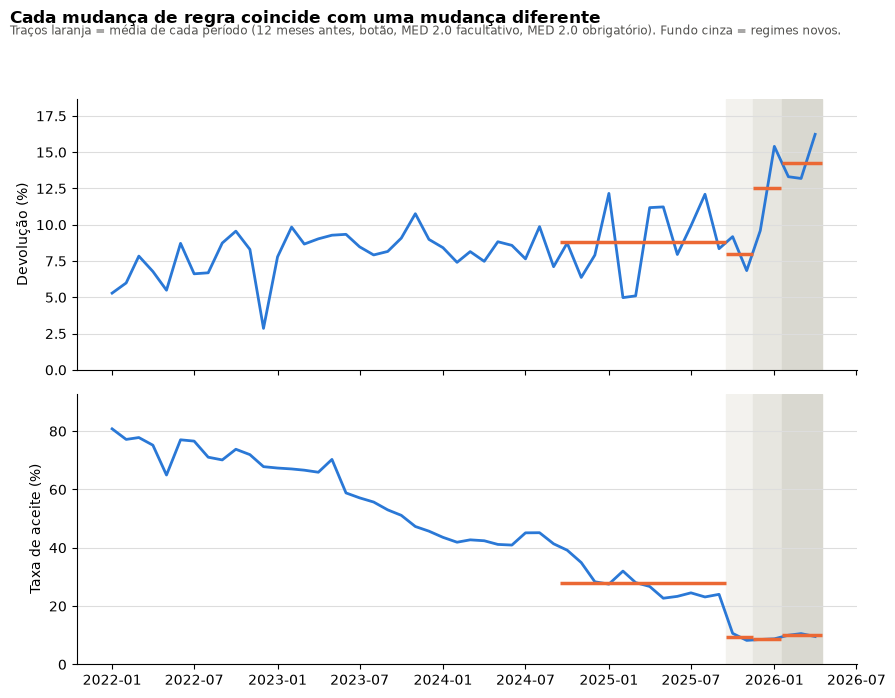

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
cores_periodo = ["#ffffff", "#ffffff", "#f3f2ee", "#e7e6e0", "#d9d8d0"]

for ax, indicador in ((ax1, "Devolução (%)"), (ax2, "Taxa de aceite (%)")):
    ax.plot(df["Data"], df[indicador], color="#2a78d6", linewidth=2)
    for (nome, inicio, fim), fundo in zip(periodos, cores_periodo):
        if nome.startswith("Antes do botão"):
            continue
        trecho = df[(df["AnoMes"] >= inicio) & (df["AnoMes"] <= fim)]
        ini_x = trecho["Data"].min() - pd.Timedelta(days=15)
        fim_x = trecho["Data"].max() + pd.Timedelta(days=15)
        if not nome.startswith("12 meses"):
            ax.axvspan(ini_x, fim_x, color=fundo, zorder=0)
        ax.hlines(trecho[indicador].mean(), ini_x, fim_x, color="#eb6834", linewidth=2.5, zorder=3)
    ax.set_ylim(0, df[indicador].max() * 1.15)
    ax.set_ylabel(indicador)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

fig.suptitle("Cada mudança de regra coincide com uma mudança diferente", x=0.01, ha="left",
             fontsize=12, fontweight="bold", y=0.99)
fig.text(0.01, 0.955,
         "Traços laranja = média de cada período (12 meses antes, botão, MED 2.0 facultativo, MED 2.0 obrigatório). "
         "Fundo cinza = regimes novos.",
         ha="left", fontsize=8.5, color="#52514e")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("../graficos/07-antes-e-depois.png", dpi=150)
plt.show()

## O que a comparação mostra

**Cada mudança de regra coincide com uma mudança diferente — e cada uma no
indicador que faria sentido ela afetar:**

- **Botão digital (out/2025) → volume e aceite, não devolução.** Os pedidos
  por milhão de transações vão de 232 (12 meses antes) para 539; a taxa de
  aceite, de 27,9% para 9,4%. A devolução fica onde estava (8,0% contra 8,8%).
  Faz sentido: o botão facilita **abrir** contestação, não recuperar dinheiro.
- **MED 2.0 (dez/2025 em diante) → devolução, não aceite.** A devolução sobe
  para 12,5% no período facultativo e 14,2% no obrigatório — os três meses do
  obrigatório ficam todos acima do máximo dos 12 meses anteriores (12,2%). A
  taxa de aceite não se mexe (8,7% e 10,0%). Faz sentido: o MED 2.0 muda **de
  onde** o dinheiro pode ser recuperado, não quem tem contestação aceita.
- **Aceitas por milhão de transações não acompanha nenhuma regra em
  particular:** 65 nos 12 meses antes, 51 no botão, 45 nos dois períodos do
  MED 2.0. É a continuação da queda que a etapa 7 já tinha achado começando em
  2025, antes de qualquer uma dessas mudanças.

**O tamanho do "antes" muda o tamanho da conclusão.** A queda da taxa de aceite
é de 51,3% para 9,4% contra os 45 meses anteriores, e de 27,9% para 9,4% contra
os 12 meses anteriores. As duas contas estão certas; a primeira só mistura a
mudança de regra com uma tendência de queda que já vinha desde 2022 (etapa 5).
Pra devolução, que era estável antes, a escolha quase não importa (8,2% contra
8,8%).

## O que não dá para afirmar

Esta é a parte que mais importa, e a que mais costuma faltar.

**Que as regras causaram as mudanças.** Antes e depois descreve o que mudou,
não prova por quê. Os motivos, um por um:

- **Amostra minúscula.** Os períodos novos têm 2, 2 e 3 meses. Com 2 meses, o
  desvio padrão é quase decorativo, e o período facultativo junta um mês baixo
  (9,6% em dez/2025) com um alto (15,4% em jan/2026) — a média de 12,5% não
  descreve nenhum dos dois.
- **As regras se sobrepõem.** Três mudanças em quatro meses. A devolução sobe
  com o MED 2.0, mas o botão digital já estava valendo — não dá pra separar o
  efeito de cada uma, nem descartar que a combinação importe.
- **As tendências já existiam.** A taxa de aceite caía desde 2022 e os pedidos
  se descolavam do Pix desde o fim de 2023 (etapas 5 e 7). Parte do "depois"
  aconteceria mesmo sem regra nova. Não há grupo de controle — todo o país
  mudou de regra ao mesmo tempo.
- **O momento do salto não bate com as datas.** A devolução sobe em jan/2026,
  entre o início facultativo e o obrigatório, não em nenhuma das duas datas.
  Adesão gradual na fase facultativa é uma explicação plausível; a tabela não
  diz quais instituições aderiram nem quando.
- **Os meses mais recentes ainda mudam.** A etapa 1 achou valores de meses
  recentes sendo revisados pelo BC entre uma consulta e outra. Os períodos
  "depois" são justamente os meses mais recentes da base.
- **Quem decide o aceite é a instituição contestada**, e fraude não contestada
  não aparece — as mesmas limitações de toda a análise.

**O que dá para afirmar com segurança:** o patamar da devolução em 2026 é
diferente de tudo que aconteceu de 2022 a 2025, não é sazonal (conferido acima), e o
momento em que ele muda é compatível com o MED 2.0 — não com o botão digital.
É uma hipótese bem fundamentada, não uma conclusão. Os próximos meses de dado
(o coletor guarda tudo) são o que pode confirmar ou derrubar.